# Practical Session: Comparison of Meteorological and Atmospheric Flux Data: Tower vs. Buoy

## 1. Introduction and Objectives
This notebook compares micrometeorological parameters and surface energy flux observations gathered simultaneously from a land-based meteorological tower (including Eddy Covariance measurements) and an offshore/lake buoy deployment.

### Key Objectives:
1. **Multi-Source Data Ingestion**: Load processed datasets from the meteorological tower, Eddy Covariance (EC) tower systems, and buoy sensor suites.
2. **Datetime Standardization**: Parse timestamps into uniform datetime indices adjusted for local timezone offsets.
3. **State Variable Comparison**: Evaluate comparative time series for primary meteorological parameters ($T_{air}$, $WS$, $WD$, $RH$, $P$).
4. **Radiative and Turbulent Flux Comparison**: Cross-compare incoming solar radiation ($S_{\uparrow}$), sensible heat flux ($H$), and latent heat flux ($LE$) between land-based tower EC systems and marine/aquatic buoy deployments.

---

## 2. Environment Setup
Import standard libraries for data handling, plotting, and file path manipulation.

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd

## 3. Data Ingestion & Index Alignment
Load tower observations, processed tower EC fluxes, and buoy time-series data, standardizing all records to unified temporal indices.

In [2]:
# File path to raw meteorological tower observations
filename = "data/pross/met_data_1h.csv"

# Load CSV data and apply timezone offset (+3 hours)
tower_df_b = pd.read_csv(filename)
tower_df_b["datetime"] = pd.to_datetime(tower_df_b["datetime"]) + pd.Timedelta(hours=3)
tower_df_b = tower_df_b.set_index("datetime")
tower_df_b = tower_df_b.loc['2024-12-06':'2024-12-12']

tower_df_b

,SUp,SDn,LUpCo,LDnCo,tair,rh,press,ws,wd,SHF
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-1.373050,64.374667,1012.819867,0.0,0.671450,-6.790317
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-1.391417,64.466667,1013.244267,0.0,0.601633,-8.338000
2024-12-06 02:00:00,-3.403450,-1.519867,212.940000,-300.505000,-1.357817,61.972167,1013.110750,0.0,0.577800,-8.456500
2024-12-06 03:00:00,-3.904550,-1.224900,214.573333,-300.468333,-1.296033,62.300667,1013.238967,0.0,0.573400,-8.127267
2024-12-06 04:00:00,-3.590267,-1.192567,215.496667,-300.398333,-1.429483,69.043833,1013.181883,0.0,0.576200,-7.540617
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 19:00:00,467.903333,-79.011000,314.971667,-358.168333,3.698367,88.823333,989.056863,0.0,1.259200,11.324500
2024-12-12 20:00:00,282.215500,-46.891833,318.570000,-356.731667,3.852717,88.481667,989.488888,0.0,1.325600,14.123000
2024-12-12 21:00:00,88.573333,-14.415017,326.713333,-346.688333,4.117917,87.811667,989.720933,0.0,1.268000,9.782200


In [3]:
# File path to processed tower EC dataset
filename = 'data/pross/data_tower.csv'
tower_df = pd.read_csv(filename, sep='\t')

# Parse datetime index
tower_df["datetime"] = pd.to_datetime(tower_df["datetime"])
tower_df = tower_df.set_index("datetime")
tower_df.columns

Index(['SUp', 'SDn', 'LUpCo', 'LDnCo', 'SHF', 'H', 'LE', 'Rn', 'SEB_Consumed',
       'SEB_Residual', 'air_temperature', 'air_pressure', 'RH', 'wind_speed',
       'wind_dir'],
      dtype='object')

In [4]:
# File path to buoy measurement dataset
filename = 'data/pross/data_buoy_full_time.csv'
bouy_df = pd.read_csv(filename, sep='\t')

# Parse datetime index
bouy_df["datetime"] = pd.to_datetime(bouy_df["datetime"])
bouy_df = bouy_df.set_index("datetime")
bouy_df.columns

Index(['ws', 'tair', 'rh', 'press', 'SUp', 'sst', 'H', 'LE'], dtype='object')

## 4. Meteorological Variables Comparison
Compare key atmospheric state variables ($T_{air}$, $WS$, $WD$, $RH$, $Press$) recorded across the tower EC station, standard tower sensor suite, and buoy platform.

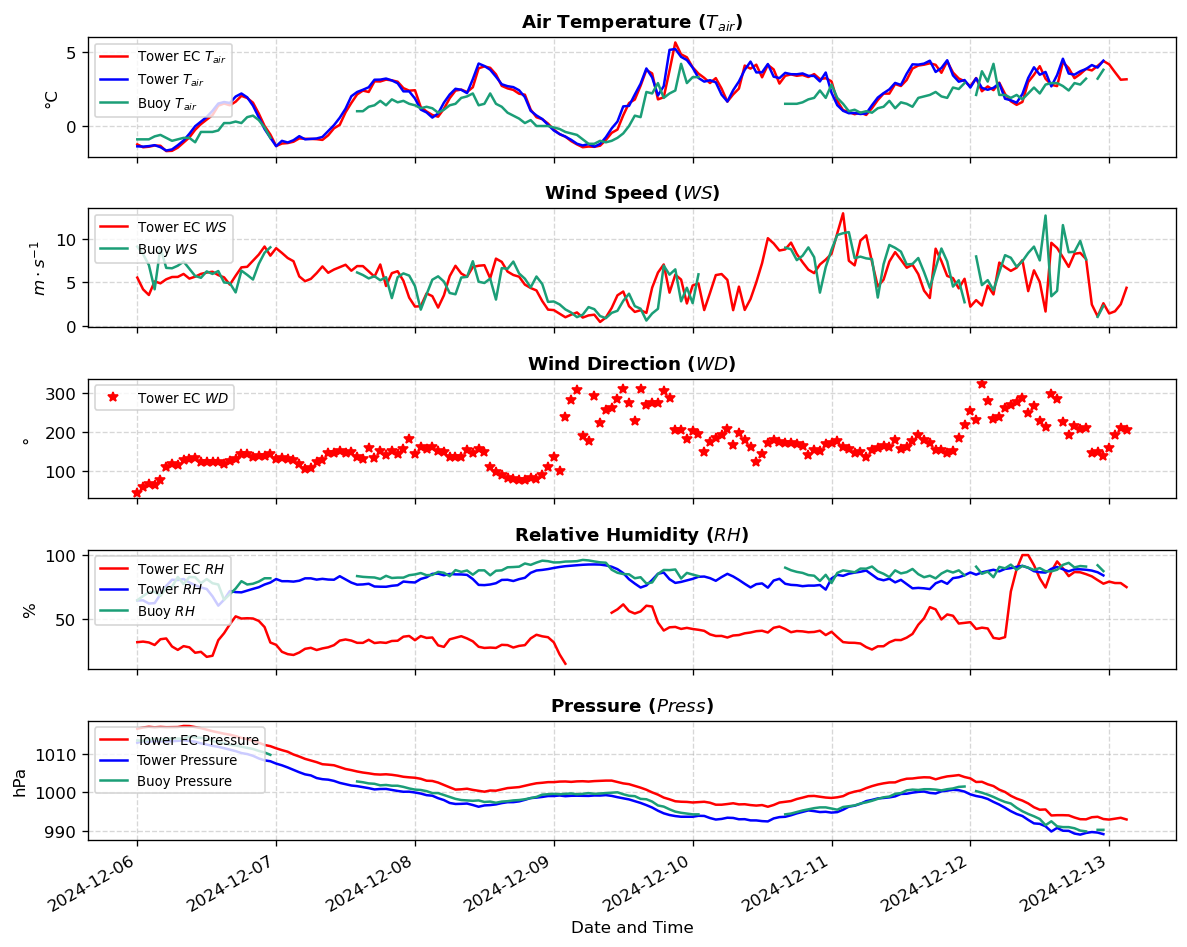

In [5]:
# Define consistent visual styles
color_tower = "red"
color_tower_l = "blue"
color_buoy = "#1b9e77"

# ==============================================================================
# FIGURE 1: Meteorological Variables (Tair, WS, WD, RH, Press)
# ==============================================================================
fig1, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(10, 8), sharex=True, dpi=120
)

# 1. Air Temperature (Tair)
ax1.plot(
    tower_df.index,
    tower_df["air_temperature"] - 273.15,
    label="Tower EC $T_{air}$",
    color=color_tower,
    linewidth=1.5,
)
ax1.plot(
    tower_df_b.index,
    tower_df_b["tair"],
    label="Tower $T_{air}$",
    color=color_tower_l,
    linewidth=1.5,
)
ax1.plot(
    bouy_df.index,
    bouy_df["tair"],
    label="Buoy $T_{air}$",
    color=color_buoy,
    linewidth=1.5,
)
ax1.set_title("Air Temperature ($T_{air}$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("°C", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Wind Speed (WS)
ax2.plot(
    tower_df.index,
    tower_df["wind_speed"],
    label="Tower EC $WS$",
    color=color_tower,
    linewidth=1.5,
)
ax2.plot(
    bouy_df.index,
    bouy_df["ws"],
    label="Buoy $WS$",
    color=color_buoy,
    linewidth=1.5,
)
ax2.set_title("Wind Speed ($WS$)", fontsize=11, fontweight="bold")
ax2.set_ylabel("$m \\cdot s^{-1}$", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 3. Wind Direction (WD)
ax3.plot(
    tower_df.index,
    tower_df["wind_dir"],
    '*',
    label="Tower EC $WD$",
    color=color_tower,
    linewidth=1.5,
)
ax3.set_title("Wind Direction ($WD$)", fontsize=11, fontweight="bold")
ax3.set_ylabel("°", fontsize=10)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 4. Relative Humidity (RH)
ax4.plot(
    tower_df.index,
    tower_df["RH"],
    label="Tower EC $RH$",
    color=color_tower,
    linewidth=1.5,
)
ax4.plot(
    tower_df_b.index,
    tower_df_b["rh"],
    label="Tower $RH$",
    color=color_tower_l,
    linewidth=1.5,
)
ax4.plot(
    bouy_df.index,
    bouy_df["rh"],
    label="Buoy $RH$",
    color=color_buoy,
    linewidth=1.5,
)
ax4.set_title("Relative Humidity ($RH$)", fontsize=11, fontweight="bold")
ax4.set_ylabel("%", fontsize=10)
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 5. Pressure (Press)
ax5.plot(
    tower_df.index,
    tower_df["air_pressure"] / 100,
    label="Tower EC Pressure",
    color=color_tower,
    linewidth=1.5,
)
ax5.plot(
    tower_df_b.index,
    tower_df_b["press"],
    label="Tower Pressure",
    color=color_tower_l,
    linewidth=1.5,
)
ax5.plot(
    bouy_df.index,
    bouy_df["press"],
    label="Buoy Pressure",
    color=color_buoy,
    linewidth=1.5,
)
ax5.set_title("Pressure ($Press$)", fontsize=11, fontweight="bold")
ax5.set_xlabel("Date and Time", fontsize=10)
ax5.set_ylabel("hPa", fontsize=10)
ax5.grid(True, linestyle="--", alpha=0.5)
ax5.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig1.autofmt_xdate()
fig1.tight_layout()

# Save figure
output_dir = "fig"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "fig_tower_bouy.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

## 5. Solar Radiation and Energy Flux Comparison
Compare solar radiation ($S_{Up}$) along with sensible ($H$) and latent ($LE$) heat fluxes between tower EC and buoy measurement stations.

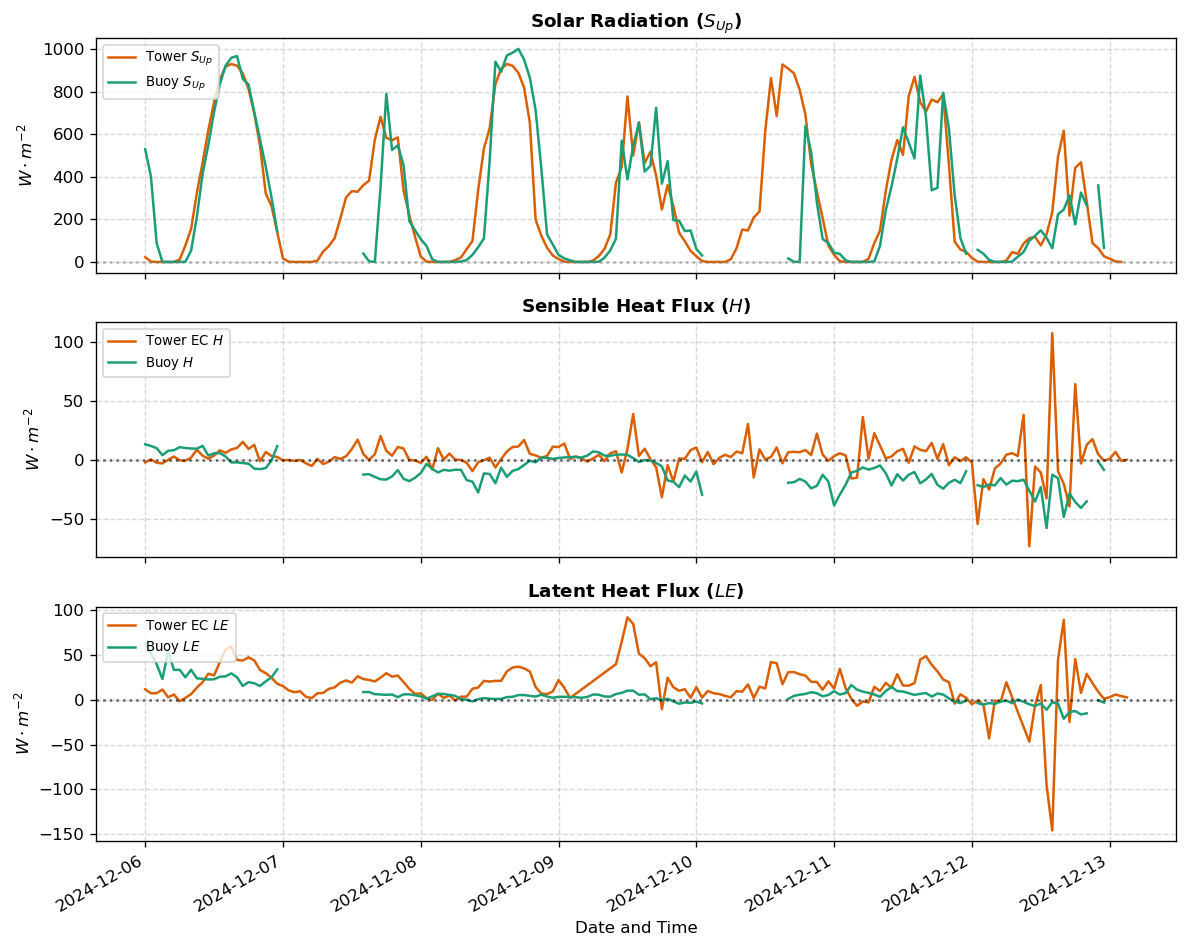

In [6]:
# Define visual styling for energy flux plots
color_tower = "#d95f02"
color_buoy = "#1b9e77"

# ==============================================================================
# FIGURE 2: Solar Radiation and Turbulent Fluxes (SUp, H, LE)
# ==============================================================================
fig2, (ax_sup, ax_h, ax_le) = plt.subplots(
    3, 1, figsize=(10, 8), sharex=True, dpi=120
)

# 1. Solar Radiation (SUp)
ax_sup.plot(
    tower_df.index,
    tower_df["SUp"],
    label="Tower $S_{Up}$",
    color=color_tower,
    linewidth=1.5,
)
ax_sup.plot(
    bouy_df.index,
    bouy_df["SUp"],
    label="Buoy $S_{Up}$",
    color=color_buoy,
    linewidth=1.5,
)
ax_sup.set_title("Solar Radiation ($S_{Up}$)", fontsize=11, fontweight="bold")
ax_sup.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_sup.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax_sup.grid(True, linestyle="--", alpha=0.5)
ax_sup.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Sensible Heat Flux (H)
ax_h.plot(
    tower_df.index,
    tower_df["H"],
    label="Tower EC $H$",
    color=color_tower,
    linewidth=1.5,
)
ax_h.plot(
    bouy_df.index,
    bouy_df["H"],
    label="Buoy $H$",
    color=color_buoy,
    linewidth=1.5,
)
ax_h.set_title("Sensible Heat Flux ($H$)", fontsize=11, fontweight="bold")
ax_h.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_h.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_h.grid(True, linestyle="--", alpha=0.5)
ax_h.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 3. Latent Heat Flux (LE)
ax_le.plot(
    tower_df.index,
    tower_df["LE"],
    label="Tower EC $LE$",
    color=color_tower,
    linewidth=1.5,
)
ax_le.plot(
    bouy_df.index,
    bouy_df["LE"],
    label="Buoy $LE$",
    color=color_buoy,
    linewidth=1.5,
)
ax_le.set_title("Latent Heat Flux ($LE$)", fontsize=11, fontweight="bold")
ax_le.set_xlabel("Date and Time", fontsize=10)
ax_le.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_le.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_le.grid(True, linestyle="--", alpha=0.5)
ax_le.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig2.autofmt_xdate()
fig2.tight_layout()
plt.show()